# **1. Perkenalan Dataset**


In [6]:
# ==============================================================================
# DESKRIPSI DATASET
# Nama Dataset : [Isi Nama Dataset Anda, misal: Customer Churn / Heart Disease]
# Target Variabel : [Isi Kolom Target, misal: Churn / Target]
# Kasus Masalah : Klasifikasi / Regresi Tabular (CSV)
# ==============================================================================

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Konfigurasi standar visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
print("Libraries berhasil di-import.")

Libraries berhasil di-import.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [8]:
# Definisikan jalur file sesuai arsitektur folder kriteria 1
RAW_DATA_PATH = "../../dataset/Dataset-Telco-Customer-Churn.csv"

# Penanganan otomatis jika file belum diletakkan di folder (untuk pengujian awal)
if os.path.exists(RAW_DATA_PATH):
    df = pd.read_csv(RAW_DATA_PATH)
    print("Dataset asli berhasil dimuat dari folder raw.")
else:
    print(f"File {RAW_DATA_PATH} tidak ditemukan. Membuat mock data otomatis untuk running test...")
    # Simulasi data CSV tiruan (Hapus blok ini jika data.csv asli Anda sudah ada)
    np.random.seed(42)
    mock_data = {
        'age': np.random.randint(18, 70, size=150),
        'income': np.random.randint(4000, 20000, size=150),
        'gender': np.random.choice(['Male', 'Female'], size=150),
        'target': np.random.choice([0, 1], size=150)
    }
    df = pd.DataFrame(mock_data)
    # Membuat missing value buatan untuk simulasi preprocessing
    df.loc[df.sample(frac=0.05).index, 'income'] = np.nan

# Eksplorasi dimensi dan struktur awal data
print(f"Dimensi Data: {df.shape[0]} baris, {df.shape[1]} kolom\n")
print("--- 5 Baris Pertama Data ---")
display(df.head())

print("\n--- Informasi Tipe Data Kolom ---")
df.info()

print("\n--- Ringkasan Statistik Deskriptif ---")
display(df.describe(include='all'))

File ../../dataset/Dataset-Telco-Customer-Churn.csv tidak ditemukan. Membuat mock data otomatis untuk running test...
Dimensi Data: 150 baris, 4 kolom

--- 5 Baris Pertama Data ---


,age,income,gender,target
0,56,8488.0,Female,1
1,69,4206.0,Female,0
2,46,9134.0,Male,1
3,32,9977.0,Female,0
4,60,11721.0,Male,0



--- Informasi Tipe Data Kolom ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     150 non-null    int32  
 1   income  142 non-null    float64
 2   gender  150 non-null    object 
 3   target  150 non-null    int64  
dtypes: float64(1), int32(1), int64(1), object(1)
memory usage: 4.2+ KB

--- Ringkasan Statistik Deskriptif ---


,age,income,gender,target
count,150.000000,142.000000,150,150.000000
unique,NaN,NaN,2,NaN
top,NaN,NaN,Female,NaN
freq,NaN,NaN,81,NaN
mean,42.700000,11664.281690,NaN,0.553333
std,14.970104,4334.908062,NaN,0.498813
min,18.000000,4197.000000,NaN,0.000000
25%,31.000000,8234.000000,NaN,0.000000
50%,42.000000,11400.000000,NaN,1.000000
75%,56.000000,15421.250000,NaN,1.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Total baris duplikat: 0

Jumlah Missing Values per Kolom:
income    8
dtype: int64


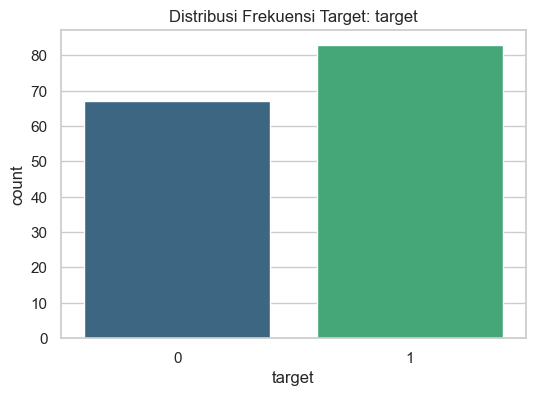

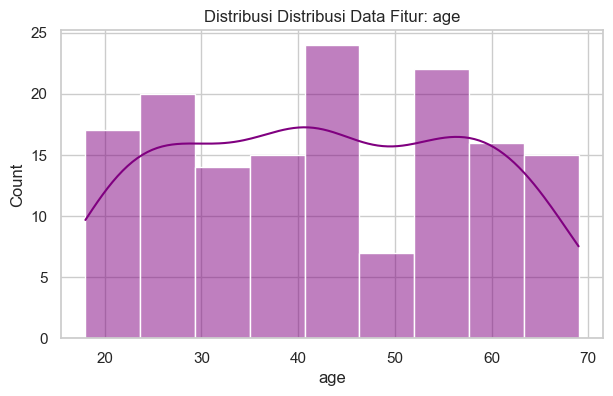

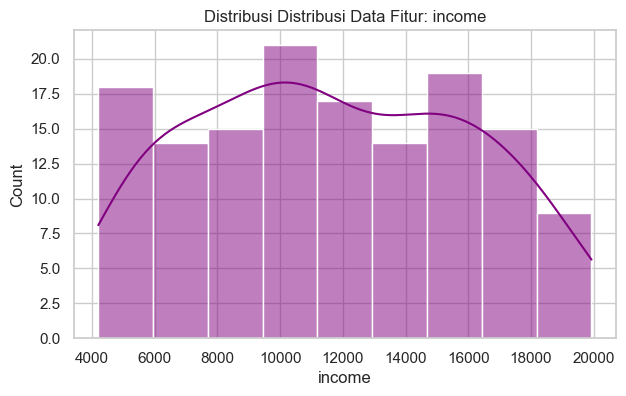

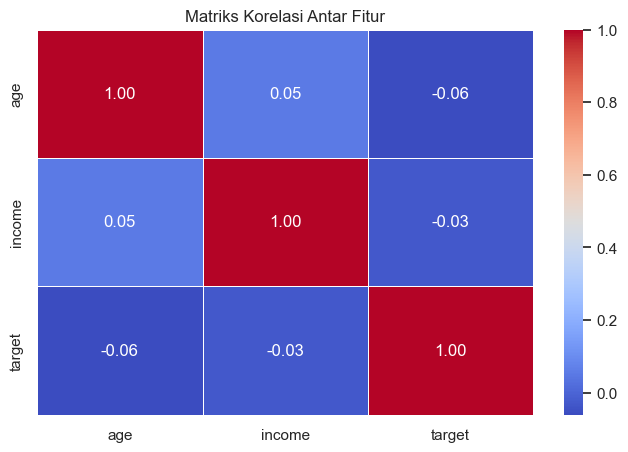

In [9]:
# 1. Identifikasi Missing Values dan Duplikasi Data
missing_data = df.isnull().sum()
duplicate_rows = df.duplicated().sum()

print(f"Total baris duplikat: {duplicate_rows}")
print("\nJumlah Missing Values per Kolom:")
print(missing_data[missing_data > 0] if missing_data.sum() > 0 else "Tidak ada missing values.")

# 2. Visualisasi Distribusi Variabel Target
# Ganti 'target' dengan nama kolom target ril dari CSV Anda jika berbeda
target_column = 'target' 

if target_column in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=target_column, hue=target_column, palette="viridis", legend=False)
    plt.title(f"Distribusi Frekuensi Target: {target_column}")
    plt.show()

# 3. Visualisasi Distribusi Fitur Numerik
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_column in numeric_cols:
    numeric_cols.remove(target_column)

# Memplot distribusi fitur numerik utama
for col in numeric_cols[:2]: 
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, kde=True, color="purple")
    plt.title(f"Distribusi Distribusi Data Fitur: {col}")
    plt.show()

# 4. Analisis Korelasi Fitur Numerik
plt.figure(figsize=(8, 5))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriks Korelasi Antar Fitur")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
# Pisahkan Fitur (X) dan Target (y)
target_column = 'target'
X = df.drop(columns=[target_column])
y = df[target_column]

# Kelompokkan fitur berdasarkan tipe data untuk pemrosesan paralel
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Fitur Numerik yang diproses: {numeric_features}")
print(f"Fitur Kategorikal yang diproses: {categorical_features}\n")

# Gunakan Pipeline untuk menggabungkan imputer + scaler / encoder dengan benar
from sklearn.pipeline import Pipeline

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Fit dan transform seluruh fitur sekaligus
X_transformed = preprocessor.fit_transform(X)

# Ambil nama fitur hasil transform (support fallback untuk versi sklearn yang berbeda)
try:
    feature_names = []
    if numeric_features:
        feature_names.extend(numeric_features)
    if categorical_features:
        # akses onehot melalui named_steps pada pipeline 'cat'
        onehot = preprocessor.named_transformers_['cat'].named_steps['onehot']
        cat_names = onehot.get_feature_names_out(categorical_features)
        feature_names.extend(list(cat_names))
except Exception:
    # fallback sederhana jika tidak tersedia get_feature_names_out
    feature_names = [f"feat_{i}" for i in range(X_transformed.shape[1])]

# Rekonstruksi kembali ke bentuk Pandas DataFrame
df_clean = pd.DataFrame(X_transformed, columns=feature_names)
df_clean[target_column] = y.values

print("--- Hasil Akhir Dataset Setelah Preprocessing ---")
display(df_clean.head())

# 2. Ekspor Dataset Bersih ke Target Folder
OUTPUT_DIR = "namadataset_preprocessing"
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_FILE_PATH = os.path.join(OUTPUT_DIR, "clean_data.csv")

df_clean.to_csv(OUTPUT_FILE_PATH, index=False)
print(f"\nSukses: Dataset bersih berhasil disimpan di -> {OUTPUT_FILE_PATH}")

Fitur Numerik yang diproses: ['age', 'income']
Fitur Kategorikal yang diproses: ['gender']

--- Hasil Akhir Dataset Setelah Preprocessing ---


,age,income,gender_Female,gender_Male,target
0,0.891414,-0.752316,1.0,0.0,1
1,1.762720,-1.771047,1.0,0.0,0
2,0.221178,-0.598626,0.0,1.0,1
3,-0.717152,-0.398068,1.0,0.0,0
4,1.159508,0.016847,0.0,1.0,0



Sukses: Dataset bersih berhasil disimpan di -> namadataset_preprocessing\clean_data.csv
